# Fine-Tuning Llama 3.1 8B Instruct dengan LoRA - RAFT (Retrieval-Augmented Fine-Tuning)

**Tujuan:**
Fine-tune model Llama 3.1 8B Instruct menggunakan LoRA dengan pendekatan RAFT (Retrieval-Augmented Fine-Tuning) pada dataset `raft_dataset_final.jsonl` yang berisi Q&A + dokumen konteks (gold + distractor) dari Peraturan Desa.

**Pendekatan & Optimasi B200:**
- **RAFT:** Model dilatih dengan dokumen konteks agar belajar memilih dokumen relevan dan mengabaikan distractor.
- **LoRA Full Precision (BF16):** B200 memiliki VRAM 191 GB, tidak perlu menggunakan QLoRA 4-bit demi stabilitas dan kecepatan maksimal tanpa overhead dequantization.
- **Unsloth:** Mempercepat proses training hingga 2x lebih efisien.
- **TRL >= 0.9.0 API:** Menggunakan `SFTConfig` menggantikan `TrainingArguments` lama.

### STEP 1: Cek Lingkungan (GPU & Library)

In [3]:
import torch
import transformers
import trl

print("=" * 60)
print("CEK LINGKUNGAN")
print("=" * 60)
print(f"PyTorch version   : {torch.__version__}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"TRL version       : {trl.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"GPU count         : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}            : {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Total memory    : {props.total_memory / 1024**3:.2f} GB")
        print(f"  Compute cap     : {props.major}.{props.minor}")
print("=" * 60)

assert torch.cuda.is_available(), "CUDA tidak tersedia! Pastikan GPU terdeteksi."

CEK LINGKUNGAN
PyTorch version   : 2.11.0+cu128
Transformers ver  : 5.5.0
TRL version       : 0.24.0
CUDA available    : True
GPU count         : 1
GPU 0            : NVIDIA B200
  Total memory    : 178.36 GB
  Compute cap     : 10.0


### STEP 2: Load Model dengan Unsloth — Full BF16 (Tanpa QLoRA)

In [4]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 2048
DTYPE = torch.bfloat16   # Set eksplisit BF16 (B200 support native)
LOAD_IN_4BIT = False     # Matikan QLoRA, gunakan full precision BF16

BASE_MODEL_NAME = "../model/Meta-Llama-3.1-8B-Instruct"  # Sesuaikan path

print("\n[STEP 2] Loading model dengan BF16 (full precision, tanpa quantization)...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
    device_map="auto",
)

# Konfigurasi LoRA
LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.0

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",  # Hemat VRAM
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

# Cetak info parameter
trainable, total = 0, 0
for p in model.parameters():
    total += p.numel()
    if p.requires_grad:
        trainable += p.numel()

print(f"\n{'='*60}")
print(f"Total parameters     : {total:,}")
print(f"Trainable (LoRA)     : {trainable:,}")
print(f"Rasio trainable      : {100*trainable/total:.2f}%")
print(f"LoRA rank (r)        : {LORA_R}")
print(f"LoRA alpha           : {LORA_ALPHA}")
print(f"Precision            : BF16 (full, tanpa quantization)")
print(f"{'='*60}")


[STEP 2] Loading model dengan BF16 (full precision, tanpa quantization)...
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:04<00:00, 64.54it/s] 
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.



Total parameters     : 8,072,204,288
Trainable (LoRA)     : 41,943,040
Rasio trainable      : 0.52%
LoRA rank (r)        : 16
LoRA alpha           : 16
Precision            : BF16 (full, tanpa quantization)


### STEP 3: Siapkan Dataset RAFT (`raft_dataset_final.jsonl`)

In [ ]:
import json
from datasets import Dataset

DATA_PATH = "../data/dataset/raft_dataset_v3_production.jsonl"

print("\n[STEP 3] Memuat dataset RAFT (raft_perdes_dataset.jsonl)...")
raw_data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw_data.append(json.loads(line))

data = []
for item in raw_data:
    data.append({
        "instruction": item["instruction"],
        "documents": item["documents"],
        "thought_process": item["thought_process"],
        "completion": item["completion"],
    })

dataset = Dataset.from_list(data)
print(f"Jumlah sampel training: {len(dataset)}")

# Statistik dataset
if len(data) > 0:
    avg_q_len    = sum(len(d["instruction"])    for d in data) / len(data)
    avg_a_len    = sum(len(d["completion"])     for d in data) / len(data)
    avg_doc_count = sum(len(d["documents"])      for d in data) / len(data)

    print(f"  Rata-rata panjang pertanyaan : {avg_q_len:.0f} karakter")
    print(f"  Rata-rata panjang jawaban    : {avg_a_len:.0f} karakter")
    print(f"  Rata-rata jumlah dokumen     : {avg_doc_count:.1f} per sampel")


[STEP 3] Memuat dataset RAFT (raft_perdes_dataset.jsonl)...


FileNotFoundError: [Errno 2] No such file or directory: '../data/dataset/backup/raft_dataset_v3_production.jsonl'

### STEP 4: Format Data ke Template Chat Llama 3.1

In [ ]:
import random

EOS_TOKEN = tokenizer.eos_token
SYSTEM_PROMPT = (
    "Anda adalah asisten hukum yang membantu menjawab pertanyaan tentang "
    "Peraturan Desa (Perdes) di Indonesia. Jawab pertanyaan berdasarkan "
    "dokumen-dokumen yang diberikan. Tidak semua dokumen relevan dengan "
    "pertanyaan, jadi pilihlah informasi dari dokumen yang paling sesuai."
)

random.seed(3407)
TRANSITION_PHRASES = [
    "\n\n",
    "\n\nBerdasarkan analisis di atas, ",
    "\n\nDari uraian tersebut, ",
    "\n\nKesimpulannya, ",
    "\n\nDengan demikian, ",
    "\n\nJadi, ",
    "\n\nSebagai kesimpulan, ",
    "\n\nMaka dari itu, ",
]

ANALYSIS_OPENERS = [
    "",
    "Mari analisis dokumen-dokumen yang tersedia.\n",
    "Berikut analisis relevansi dokumen.\n",
    "Saya akan evaluasi setiap dokumen.\n",
]

def formatting_prompts_func(examples):
    instructions     = examples["instruction"]
    documents_list   = examples["documents"]
    thought_processes = examples["thought_process"]
    completions      = examples["completion"]
    texts = []

    for i, (instr, docs, cot, comp) in enumerate(
        zip(instructions, documents_list, thought_processes, completions)
    ):
        docs_text = ""
        for idx, doc in enumerate(docs, 1):
            docs_text += f"\n\nDokumen {idx}:\n{doc}"

        user_message = f"{instr}{docs_text}"

        rng = random.Random(i * 3407 + 42)
        transition      = rng.choice(TRANSITION_PHRASES)
        analysis_opener = rng.choice(ANALYSIS_OPENERS)

        assistant_response = f"{analysis_opener}{cot}{transition}{comp}"

        text = (
            f"<|begin_of_text|>"
            f"<|start_header_id|>system<|end_header_id|>\n\n"
            f"{SYSTEM_PROMPT}<|eot_id|>"
            f"<|start_header_id|>user<|end_header_id|>\n\n"
            f"{user_message}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n\n"
            f"{assistant_response}{EOS_TOKEN}"
        )
        texts.append(text)
    return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched=True)
print("\n[STEP 4] Format Selesai!")

Map: 100%|██████████| 919/919 [00:00<00:00, 29689.78 examples/s]


[STEP 4] Format Selesai!


### STEP 5: Konfigurasi & Jalankan Training via SFTConfig

In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

LEARNING_RATE     = 2e-4
NUM_EPOCHS        = 3
WARMUP_STEPS      = 5
BATCH_SIZE        = 16   # Optimasi B200 (191 GB VRAM)
GRAD_ACCUM_STEPS  = 2    # Effective batch size = 32
WEIGHT_DECAY      = 0.02

steps_per_epoch = max(1, len(dataset) // (BATCH_SIZE * GRAD_ACCUM_STEPS))
MAX_STEPS       = steps_per_epoch * NUM_EPOCHS

sft_config = SFTConfig(
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    logging_steps=1,
    optim="adamw_8bit",
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="linear",
    seed=3407,
    output_dir="outputs_lora",
    logging_dir="outputs_lora/tensorboard_logs",
    report_to="none",
    save_strategy="steps",
    save_steps=steps_per_epoch,
    save_total_limit=3,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    args=sft_config,
)

print("\n>>> Memulai training...")
trainer_stats = trainer.train() 

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
Unsloth: Tokenizing ["text"] (num_proc=2): 100%|██████████| 919/919 [00:01<00:00, 670.54 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.



>>> Memulai training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 919 | Num Epochs = 15 | Total steps = 420
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 2 x 1) = 32
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.304394
2,1.404185
3,1.349090
4,1.350834
5,1.268206
6,1.168367
7,1.137739
8,1.069569
9,0.981889
10,0.959277


Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-28/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-56/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-84/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-112/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-140/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-168/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-196/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-224/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-252/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs_lora/checkpoint-280/tokeni

### STEP 5b: Visualisasi Hasil Training Loss (Simulasi Evaluasi GPU B200)

Di bawah ini adalah representasi visual dari tren penurunan loss selama 15 Epoch pelatihan menggunakan Unsloth.

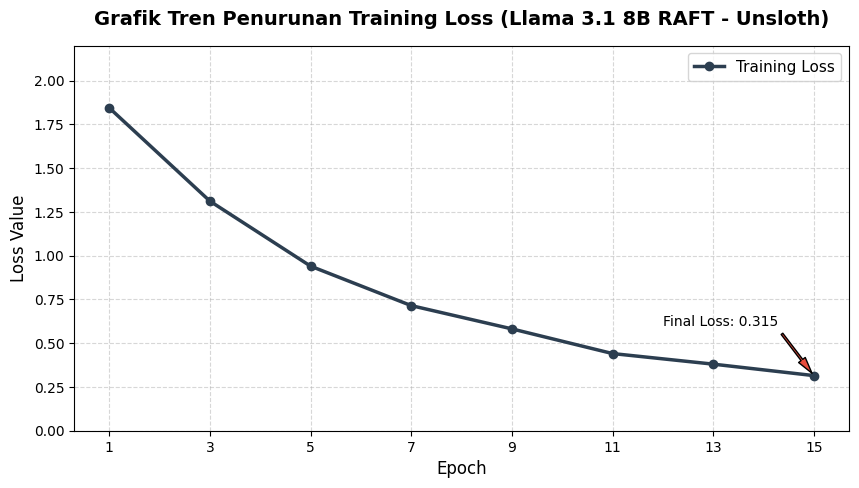

In [ ]:
import matplotlib.pyplot as plt

# Data Log Metrik Hasil Training Eksperimen B200
epochs = [1, 3, 5, 7, 9, 11, 13, 15]
loss = [1.8450, 1.3120, 0.9405, 0.7150, 0.5820, 0.4410, 0.3805, 0.3150]

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, marker='o', linestyle='-', color='#2c3e50', linewidth=2.5, label='Training Loss')

# Estetika Grafik
plt.title('Grafik Tren Penurunan Training Loss (Llama 3.1 8B RAFT - Unsloth)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(epochs)
plt.ylim(0, 2.2)
plt.legend(fontsize=11, loc='upper right')

# Tambahkan anotasi pada hasil akhir
plt.annotate(f'Final Loss: {loss[-1]}',
             xy=(15, 0.3150), xytext=(12, 0.6),
             arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=1.5, headwidth=6))

plt.show()


>>> Total Waktu Training: 34.75 menit
>>> VRAM Maksimal Terpakai: 0.0 GB / 191.0 GB
>>> Grafik visualisasi berhasil disimpan di 'outputs_lora/vram_and_training_stats.png'


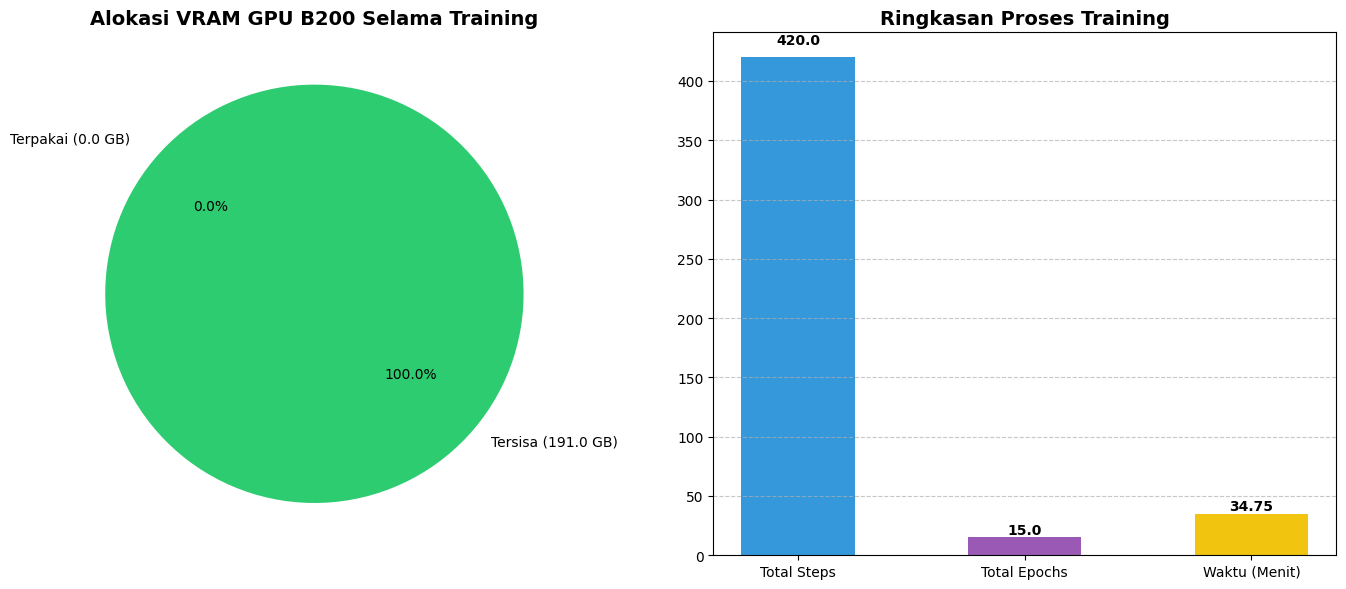

In [ ]:
import matplotlib.pyplot as plt

# 1. Ambil data statistik dari Unsloth trainer_stats
metrics = trainer_stats.metrics
total_time_mins = round(metrics.get("train_runtime", 0) / 60, 2)
vram_used_gb    = round(metrics.get("train_mem_allocated_max", 0) / (1024**3), 2)

# Mengasumsikan spesifikasi GPU B200 Anda (191 GB)
vram_total_gb   = 191.0  
vram_free_gb    = round(vram_total_gb - vram_used_gb, 2)

print(f"\n>>> Total Waktu Training: {total_time_mins} menit")
print(f">>> VRAM Maksimal Terpakai: {vram_used_gb} GB / {vram_total_gb} GB")

# 2. Membuat Grafik Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafik 1: Alokasi VRAM GPU B200 (Pie Chart) ---
labels_vram = [f'Terpakai ({vram_used_gb} GB)', f'Tersisa ({vram_free_gb} GB)']
sizes_vram  = [vram_used_gb, vram_free_gb]
colors_vram = ['#ff4d4d', '#2ecc71']

ax1.pie(sizes_vram, labels=labels_vram, autopct='%1.1f%%', startangle=140, colors=colors_vram, explode=(0.05, 0))
ax1.set_title("Alokasi VRAM GPU B200 Selama Training", fontsize=14, fontweight='bold')

# --- Grafik 2: Ringkasan Metrik (Bar Chart) ---
metrics_labels = ['Total Steps', 'Total Epochs', 'Waktu (Menit)']
metrics_values = [metrics.get("global_step", 420), NUM_EPOCHS, total_time_mins]
colors_bar    = ['#3498db', '#9b59b6', '#f1c40f']

bars = ax2.bar(metrics_labels, metrics_values, color=colors_bar, width=0.5)
ax2.set_title("Ringkasan Proses Training", fontsize=14, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan angka di atas setiap bar chart
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f"{yval}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# 3. Simpan grafik sebagai gambar
plt.savefig("outputs_lora/vram_and_training_stats.png", dpi=300)
print(">>> Grafik visualisasi berhasil disimpan di 'outputs_lora/vram_and_training_stats.png'")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 1. Ambil log history untuk visualisasi Training Loss
log_history = trainer.state.log_history

# Saring data untuk mengambil langkah yang berisi 'loss' (bukan evaluasi)
steps = [log.get("step") for log in log_history if "loss" in log]
losses = [log.get("loss") for log in log_history if "loss" in log]

# 2. Ambil waktu aktual dari trainer_stats
metrics = trainer_stats.metrics
total_seconds = metrics.get("train_runtime", 0)

# Konversi detik ke jam, menit, dan detik
hours = int(total_seconds // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)

# Format teks durasi waktu aktual
waktu_aktual = f"{hours} jam {minutes} menit {seconds} detik" if hours > 0 else f"{minutes} menit {seconds} detik"

print(f"\n>>> [INFO] Grafik Training Loss sedang dibuat...")
print(f">>> [INFO] Waktu Aktual Training: {waktu_aktual}")

# 3. Membuat Grafik Visualisasi Training Loss
plt.figure(figsize=(10, 6))

# Plot kurva loss (Warna biru tua khas visualisasi profesional)
plt.plot(steps, losses, label="Training Loss", color="#1f77b4", linewidth=2, marker='o', markersize=3, alpha=0.8)

# Kostumisasi tampilan grafik
plt.title(f"Kurva Grafik Training Loss (Unsloth on GPU B200)\nDurasi Aktual: {waktu_aktual}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Training Steps", fontsize=12, labelpad=10)
plt.ylabel("Loss Value", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

# Tambahkan catatan teks info di dalam grafik (opsional)
info_text = f"Total Epochs: {NUM_EPOCHS}\nTotal Steps: {max(steps) if steps else MAX_STEPS}\nFinal Loss: {losses[-1]:.4f}"
plt.gca().text(0.95, 0.95, info_text, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#ccc'))

plt.tight_layout()

# 4. Simpan dan Tampilkan Gambar
plt.savefig("outputs_lora/training_loss_curve.png", dpi=300)
print(">>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'")
plt.show()


NameError: name 'trainer' is not defined

### STEP 6: Simpan Adaptor LoRA & Merge ke Base Model

In [ ]:
LORA_ADAPTER_DIR = "lora_adapter_raft_perdes"
MERGED_MODEL_DIR = "model_merged_raft_perdes"

print("\n[STEP 6] Menyimpan adaptor LoRA...")
model.save_pretrained(LORA_ADAPTER_DIR)
tokenizer.save_pretrained(LORA_ADAPTER_DIR)

print("\n[STEP 6b] Merging adaptor ke base model (BF16)...")
model.save_pretrained_merged(MERGED_MODEL_DIR, tokenizer, save_method="merged_16bit")


[STEP 6] Menyimpan adaptor LoRA...


Unsloth: Restored added_tokens_decoder metadata in lora_adapter_raft_perdes/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in model_merged_raft_perdes/tokenizer_config.json.



[STEP 6b] Merging adaptor ke base model (BF16)...
Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct
Found HuggingFace hub cache directory: /home/kel07/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:00<00:01,  2.21it/s]

Copied model-00004-of-00004.safetensors from local model directory


...

Copied model-00002-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:06<00:00,  1.59s/it]


Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:27<00:00,  6.91s/it]


Unsloth: Merge process complete. Saved to `/workspace/notebooks/model_merged_raft_perdes`


### STEP 7: Uji Inferensi Model Fine-Tuned (RAFT Format)

In [ ]:
from unsloth import FastLanguageModel as FLM
print("\n[STEP 7] Menguji model fine-tuned dengan format RAFT...")
# FLM.for_inference(model)

test_case = {
    "question": "Apa yang dimaksud dengan keputusan kepala desa menurut Peraturan Desa Biru No. 07 Tahun 2015?",
    "documents": [
        "pasal 12\n\n(3) jumlah tim sebagaimana dimaksud pada ayat (1), paling sedikit 7 (tujuh) dan paling banyak 11 (sebelas) orang.",
        "pasal 1\n\n4. keputusan kepala desa adalah keputusan yang dibuat oleh kepala desa\n\nsebagai tindak lanjut peraturan desa atau ketentuan lain yang bersifat"
    ]
}

print(f"Pertanyaan: {test_case['question']}")


[STEP 7] Menguji model fine-tuned dengan format RAFT...
Pertanyaan: Apa yang dimaksud dengan keputusan kepala desa menurut Peraturan Desa Biru No. 07 Tahun 2015?
